In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from esda.geary import Geary

import warnings

In [ ]:
nta_gdf = gpd.read_file("..\\Dataset\\NYC_DWT_Analysis\\nynta2020_25d\\nynta2020.shp")
print(nta_gdf.columns)
nta_gdf['NTA2020'] = nta_gdf["NTA2020"].astype(str).str.lower()

print(nta_gdf["NTA2020"])

Index(['BoroCode', 'BoroName', 'CountyFIPS', 'NTA2020', 'NTAName', 'NTAAbbrev',
       'NTAType', 'CDTA2020', 'CDTAName', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='object')
0      bk0101
1      bk0102
2      bk0103
3      bk0104
4      bk0201
        ...  
257    si0391
258    si9561
259    si9591
260    si9592
261    si9593
Name: NTA2020, Length: 262, dtype: object


In [26]:
years = [2021.0, 2022.0, 2023.0]
boroughs = ['manhattan', 'brooklyn', 'bronx', 'queens']

borough_year_data = {}
for y in years:
    borough_year_data[y] = {} 
    print(f"\nLoading {y} data")
    for b in boroughs:
        file_path = f"..\\Dataset\\{y}\\{b}.csv"
        borough_year_data[y][b] = pd.read_csv(file_path)
        print(f"Loaded {b} data")


Loading 2021.0 data
Loaded manhattan data
Loaded brooklyn data
Loaded bronx data
Loaded queens data

Loading 2022.0 data
Loaded manhattan data
Loaded brooklyn data
Loaded bronx data
Loaded queens data

Loading 2023.0 data
Loaded manhattan data
Loaded brooklyn data
Loaded bronx data
Loaded queens data


In [27]:
allNTAs = nta_gdf["NTA2020"].unique()
NTAsList = set()

for y in years:
    for b in boroughs:
        NTAsList.update(borough_year_data[y][b]["NTA_Code"].str.lower().str.strip().unique())
        print(f"Included NTA codes from {b} in {y}")

NTAsList = pd.DataFrame(list(NTAsList), columns=["NTA2020"])

Included NTA codes from manhattan in 2021.0
Included NTA codes from brooklyn in 2021.0
Included NTA codes from bronx in 2021.0
Included NTA codes from queens in 2021.0
Included NTA codes from manhattan in 2022.0
Included NTA codes from brooklyn in 2022.0
Included NTA codes from bronx in 2022.0
Included NTA codes from queens in 2022.0
Included NTA codes from manhattan in 2023.0
Included NTA codes from brooklyn in 2023.0
Included NTA codes from bronx in 2023.0
Included NTA codes from queens in 2023.0


NTA Codes not included in dataset: 106


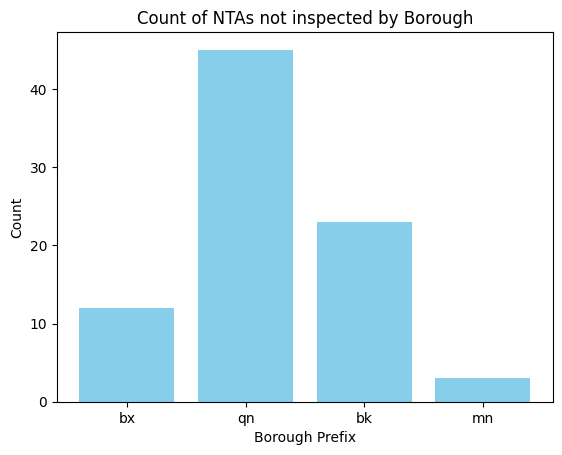

In [28]:
print(f"NTA Codes not included in dataset: {len(set(allNTAs) - set(NTAsList['NTA2020']))}")

NTA_Prefix = ['bx', 'qn', 'bk', 'mn']
counts = {pre: len([s for s in set(allNTAs) - set(NTAsList['NTA2020']) if s.startswith(pre)]) for pre in NTA_Prefix}

# Plot
plt.bar(counts.keys(), counts.values(), color='skyblue')
plt.xlabel("Borough Prefix")
plt.ylabel("Count")
plt.title("Count of NTAs not inspected by Borough")
plt.show()

In [29]:
#NTA aggregation, just as before
nta_data = {}
for y in years:
    nta_data[y] = {}
    for b in boroughs:
        df = borough_year_data[y][b].copy()

        df["has_violation"] = (df["Violation_Code"] != '0').astype(int)
        df["is_audit"] = (df["Activity_Type"] == "nyc health department audit").astype(int)

        agg = df.groupby('NTA_Code').agg(   inspection_count = ("BIN", "count"),
                                            violation_count = ("has_violation", "sum"),
                                            total_dwt = ('Number of DWT', "sum"),
                                            audit_count = ("is_audit", "sum"), ).reset_index()

        agg["violation_rate"] = agg["violation_count"]/agg["inspection_count"]
        agg["avg_dwt"]        = agg["total_dwt"]/agg["inspection_count"]
        agg["audit_fraction"] = agg["audit_count"]/agg["inspection_count"]

        nta_data[y][b] = agg.drop(columns=["violation_count", "total_dwt", "audit_count"])

In [30]:
#Borough-wise merging of NTA aggregates
NTA_Prefix = {'bronx': 'bx', 'queens': 'qn', 'brooklyn': 'bk', 'manhattan': 'mn'}

geo_data = {}
for y in years:
    geo_data[y] = {}
    for b in boroughs:
        prefix = NTA_Prefix[b]
        borough_shape = nta_gdf[nta_gdf["NTA2020"].str.startswith(prefix)].copy()
        merged = borough_shape.merge( nta_data[y][b], left_on  = "NTA2020", right_on = "NTA_Code", how= "left")

        for col in ["inspection_count", "violation_rate", "avg_dwt", "audit_fraction"]:
            merged[col] = merged[col].fillna(0)

        geo_data[y][b] = merged.reset_index(drop=True)

In [31]:
#Defining locality/neighbourness weights in 2 ways: K Nearest Neighbours and Queen weights (KNN with K=8)
weights_queen = {}
weights_knn   = {}

for b in boroughs:
    gdf = geo_data[years[0]][b]
    weights_queen[b] = Queen.from_dataframe(gdf, silence_warnings=True)
    weights_knn[b]   = KNN.from_dataframe(gdf, k=5, silence_warnings=True)
    weights_queen[b].transform = "r"
    weights_knn[b].transform   = "r"
    print(f"Weights built — {b}: {weights_queen[b].n} NTAs.")

C:\Users\adity\AppData\Local\Temp\ipykernel_10816\2909715720.py:7: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  weights_queen[b] = Queen.from_dataframe(gdf, silence_warnings=True)


Weights built — manhattan: 38 NTAs.
Weights built — brooklyn: 69 NTAs.
Weights built — bronx: 49 NTAs.
Weights built — queens: 83 NTAs.


In [32]:
#Global Autocorrelation analysis
global_results = []

for y in years:
    for b in boroughs:
        gdf = geo_data[y][b]
        for w_name, w in [("Queen", weights_queen[b]), ("KNN-5", weights_knn[b])]:
            for var in ["inspection_count", "violation_rate"]:
                vals = gdf[var].values
                mi   = Moran(vals, w)
                gc   = Geary(vals, w)

                global_results.append({
                    "year":     int(y),
                    "borough":  b,
                    "weights":  w_name,
                    "variable": var,
                    "morans_i": round(mi.I, 4),
                    "moran_p":  round(mi.p_sim, 4),
                    "gearys_c": round(gc.C, 4),
                    "geary_p":  round(gc.p_sim, 4),
                })

global_df = pd.DataFrame(global_results)

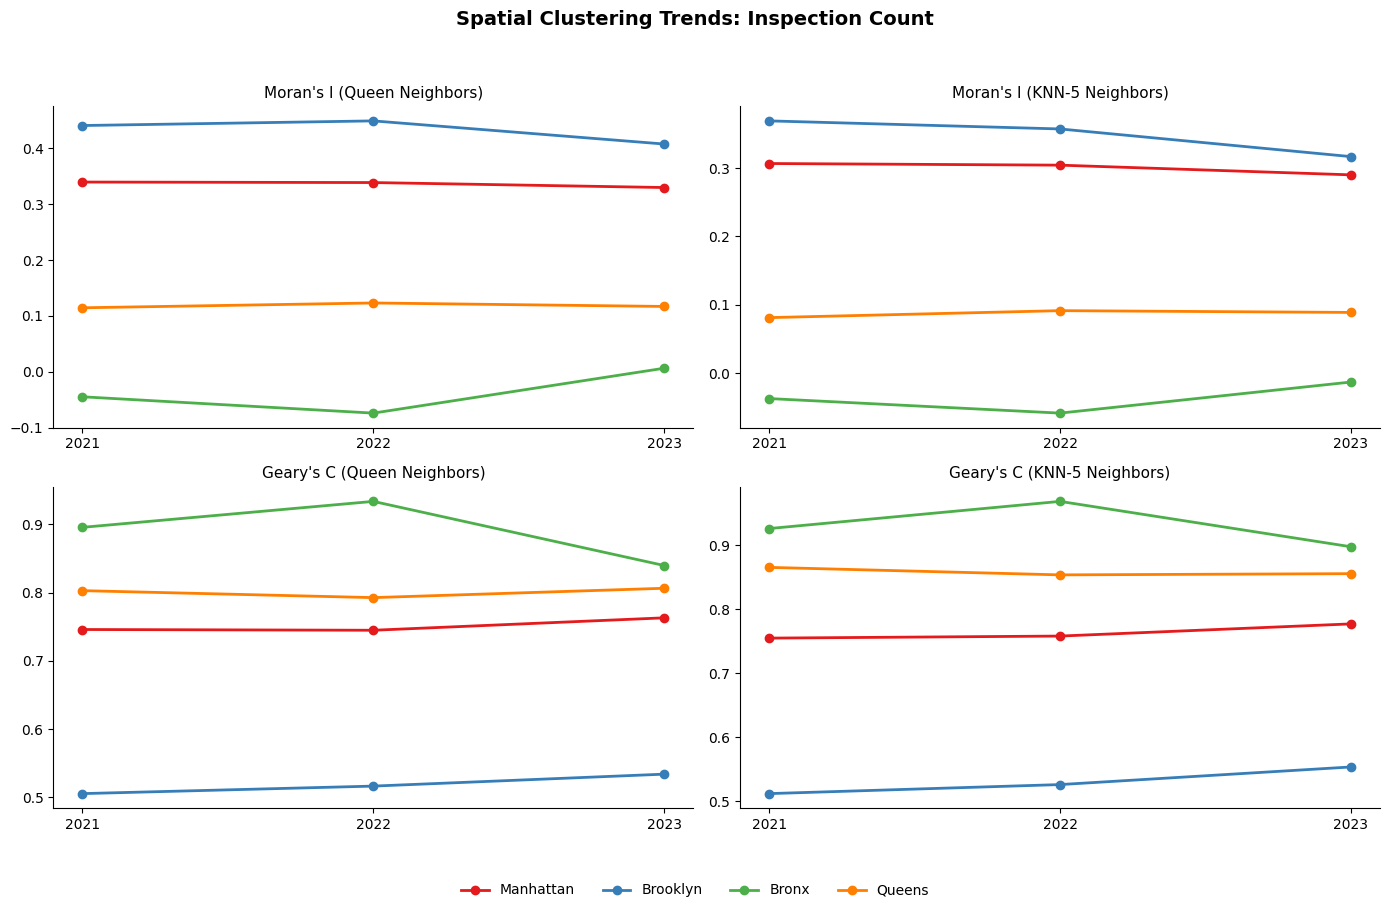

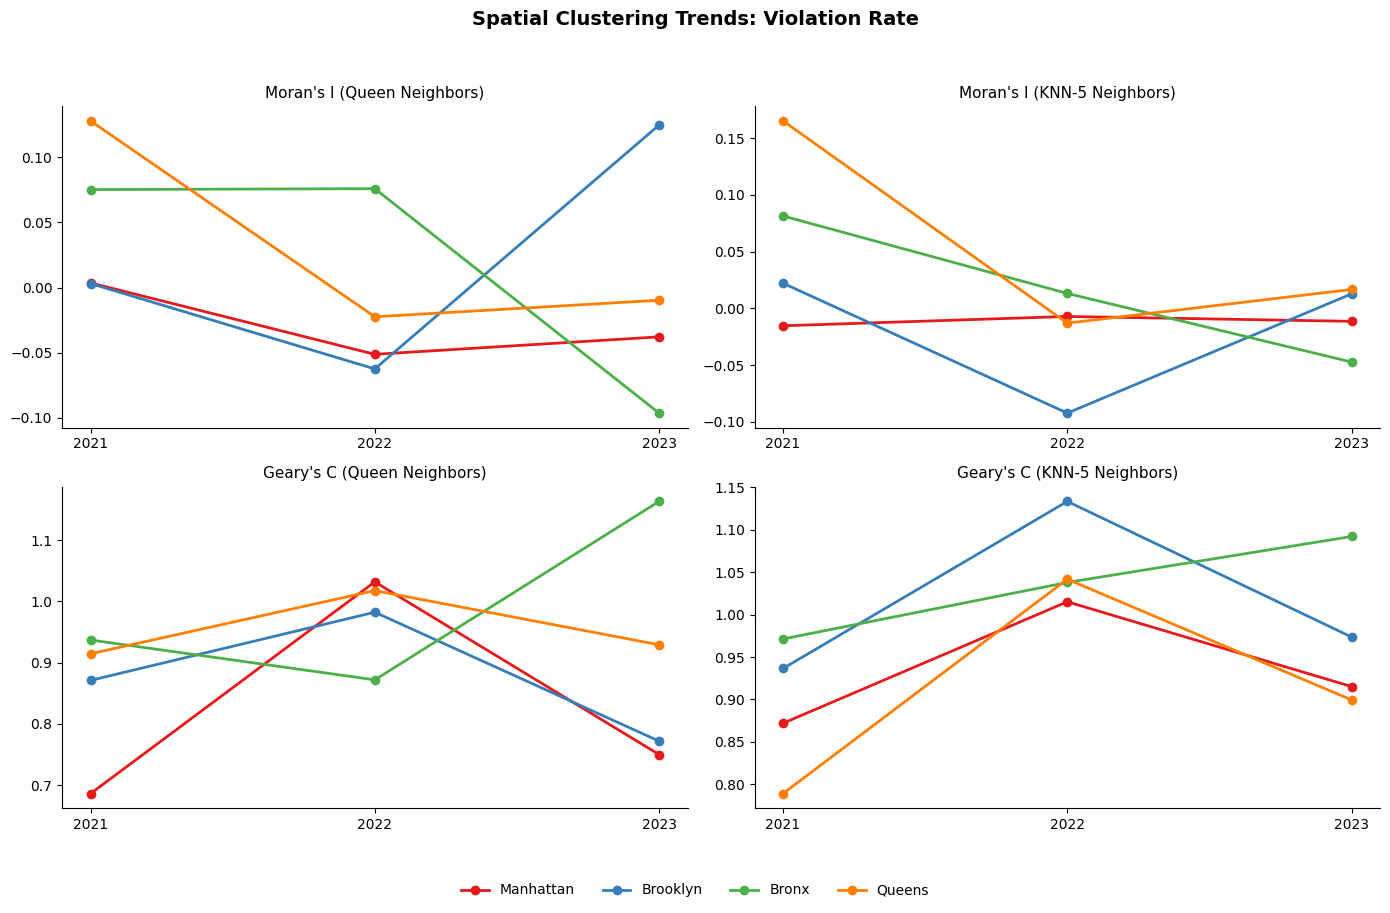

In [33]:
# Mapping boroughs to distinct colors for the project report
BOROUGH_COLORS = {
    "manhattan": "#e41a1c",
    "brooklyn":  "#377eb8",
    "bronx":     "#4daf4a",
    "queens":    "#ff7f00",
}

for variable_name in ["inspection_count", "violation_rate"]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    
    title_text = variable_name.replace('_', ' ').title()
    fig.suptitle(f"Spatial Clustering Trends: {title_text}", fontsize=14, fontweight="bold")

    stats_to_plot = [
        {"val": "morans_i", "p": "moran_p", "label": "Moran's I", "ref": 0},
        {"val": "gearys_c", "p": "geary_p", "label": "Geary's C", "ref": 1}
    ]

    for row, stat in enumerate(stats_to_plot):
        for col, weight_type in enumerate(["Queen", "KNN-5"]):
            ax = axes[row, col]
            
            plot_data = global_df[
                (global_df["variable"] == variable_name) & 
                (global_df["weights"] == weight_type)
            ]

            for b_name in boroughs:
                b_stats = plot_data[plot_data["borough"] == b_name].sort_values("year")
                b_color = BOROUGH_COLORS.get(b_name, "gray")

                #Main trend line
                ax.plot(b_stats["year"], b_stats[stat["val"]], marker="o", label=b_name.title(), color=b_color, linewidth=2)

            
            # Formatting the subplot
            ax.set_title(f"{stat['label']} ({weight_type} Neighbors)", fontsize=11)
            ax.set_xticks([int(y) for y in years])
            ax.spines[["top", "right"]].set_visible(False)

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(boroughs), bbox_to_anchor=(0.5, -0.02), frameon=False)

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()

In [34]:
#Calculating LISA
local_results = {}

for y in years:
    local_results[y] = {}
    for b in boroughs:
        local_results[y][b] = {}
        gdf = geo_data[y][b]
        w   = weights_queen[b]

        for var in ["inspection_count", "violation_rate"]:
            vals = gdf[var].values
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                local_results[y][b][var] = Moran_Local(vals, w, permutations=999)

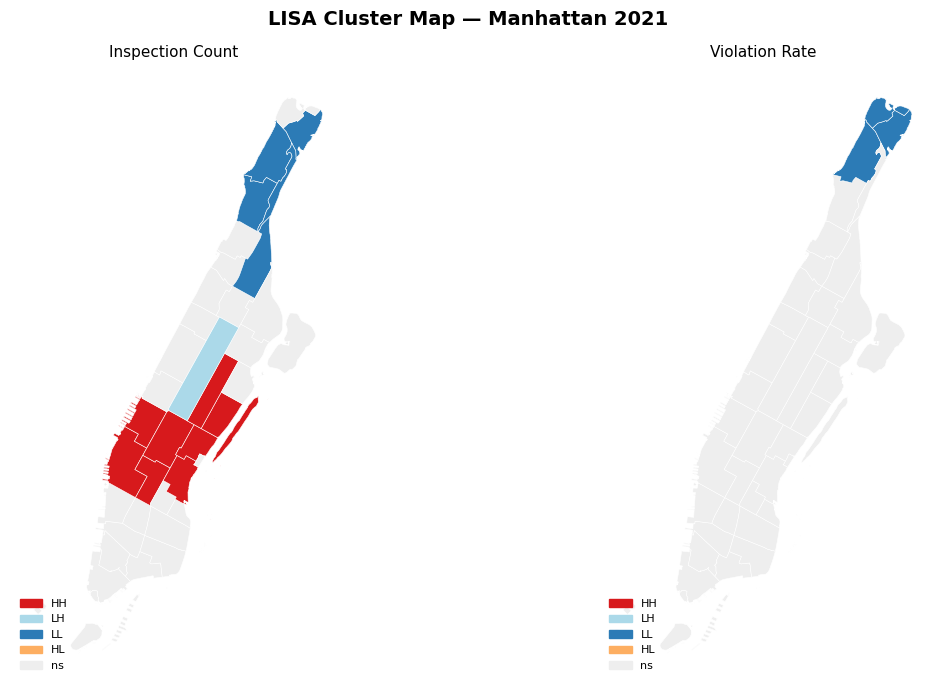

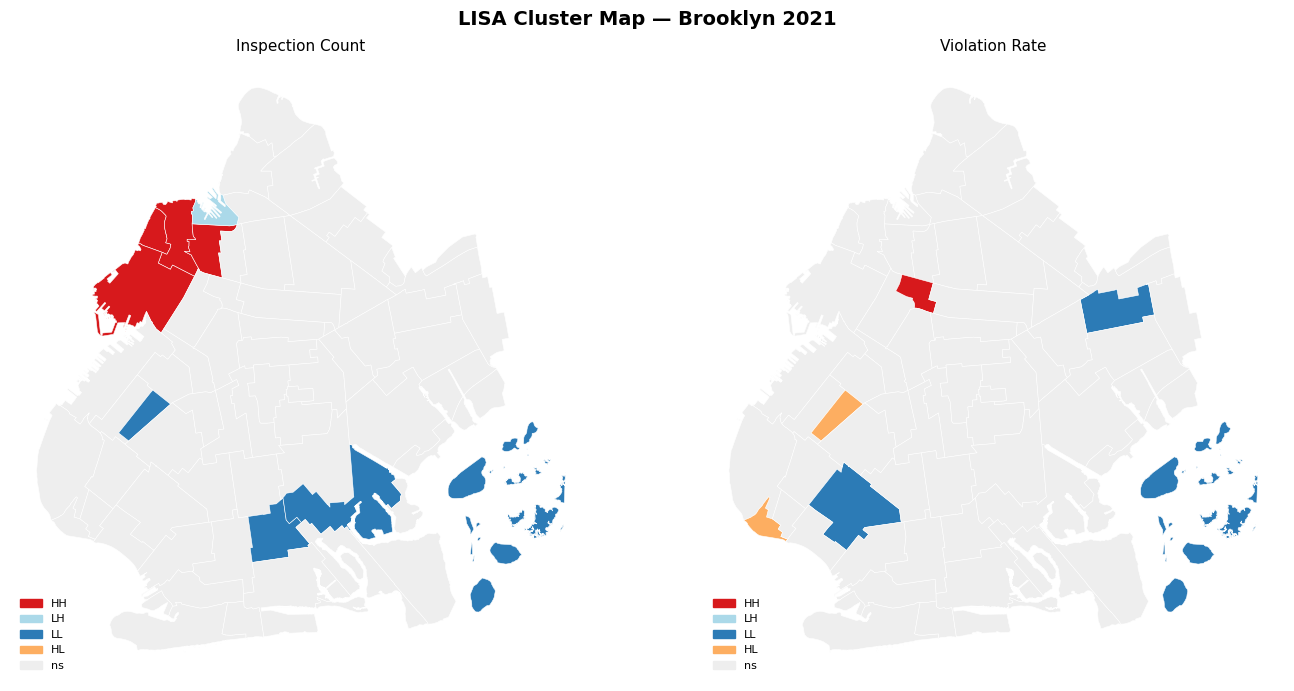

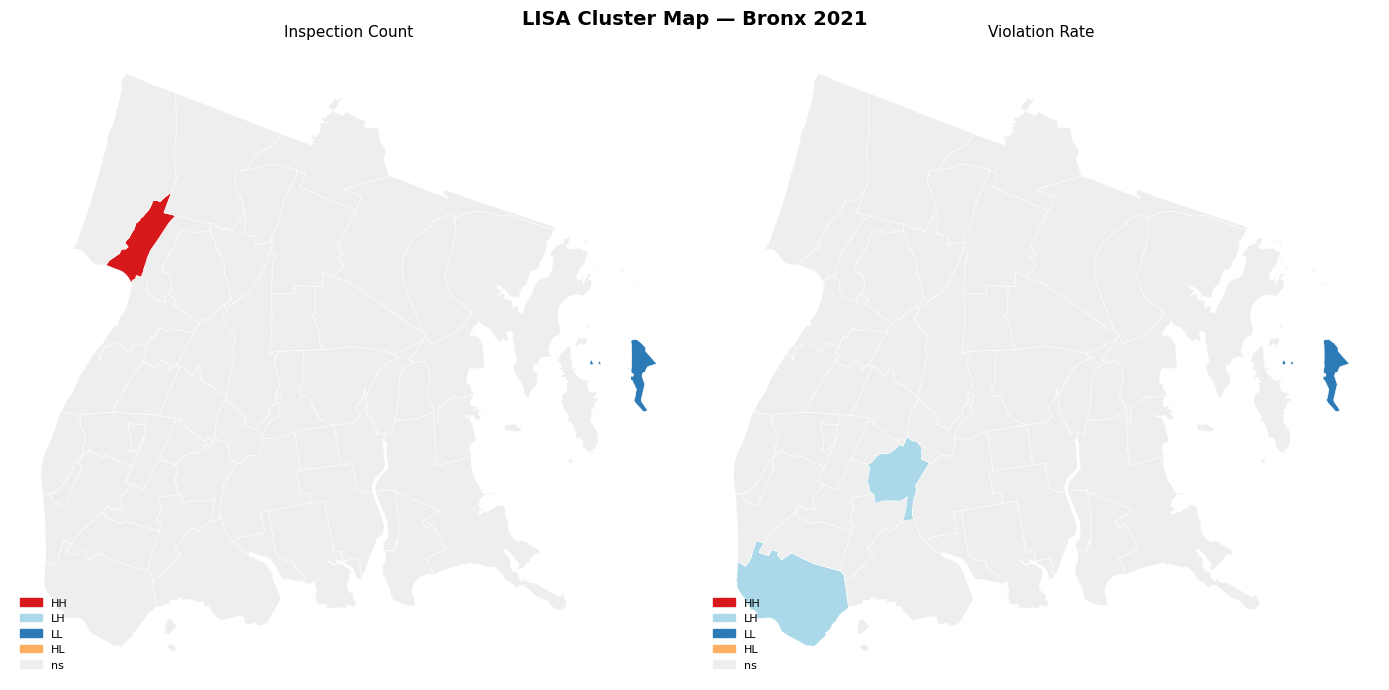

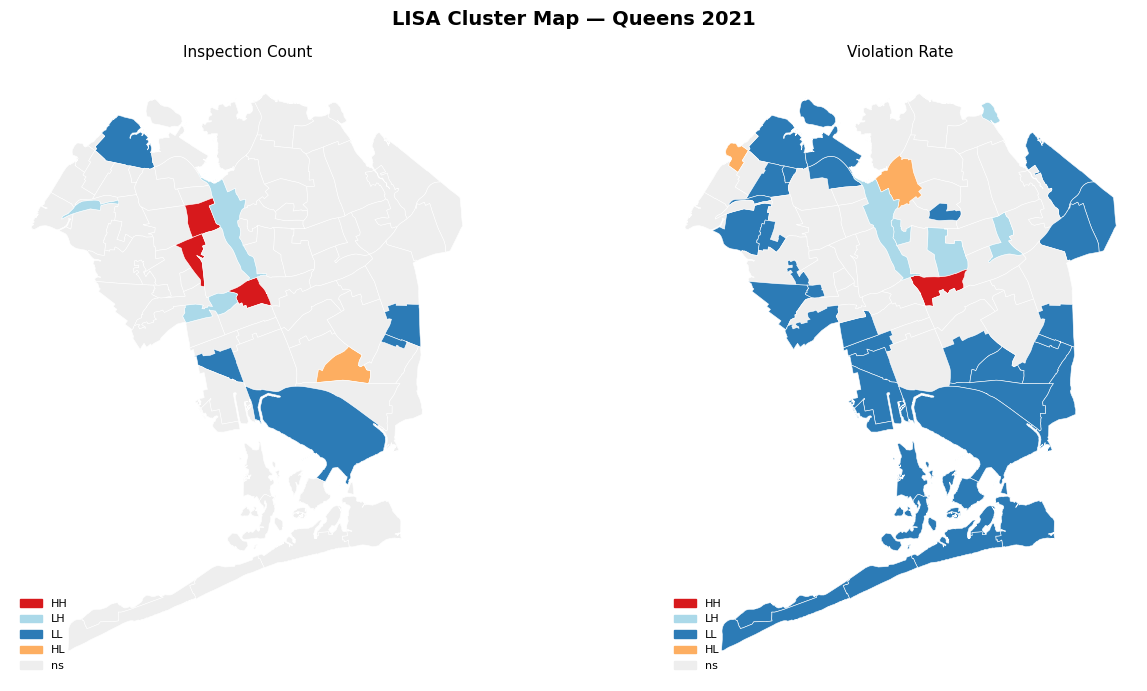

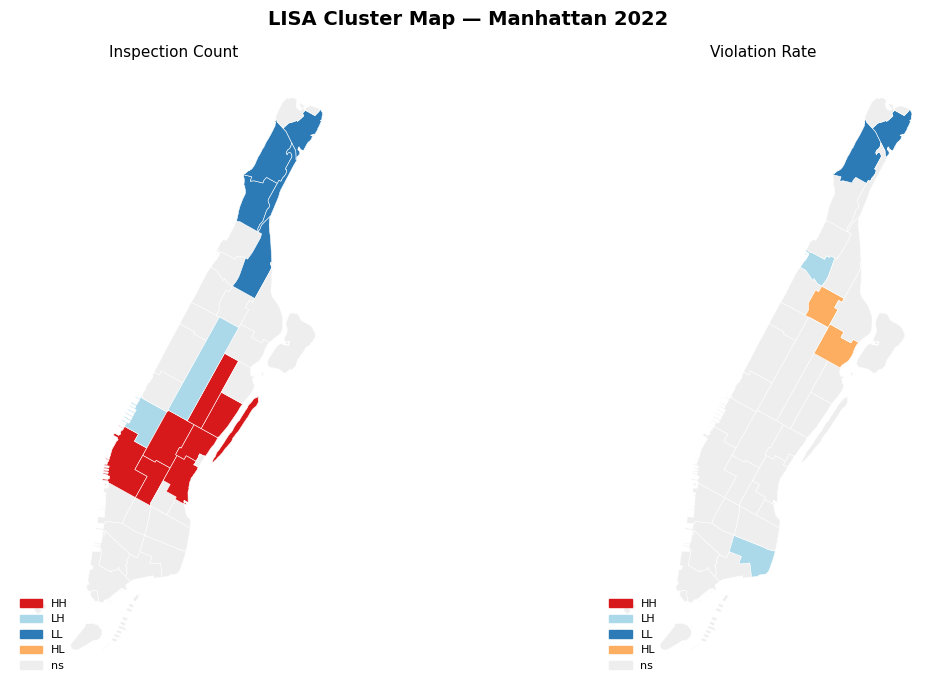

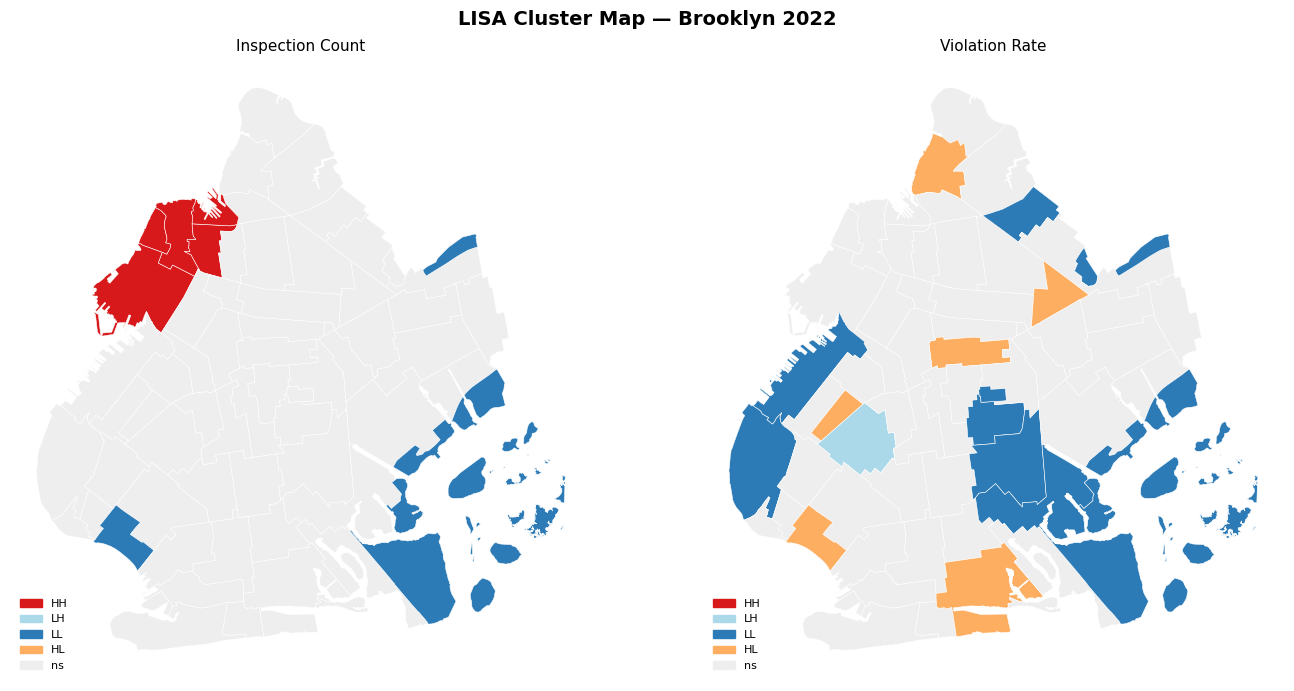

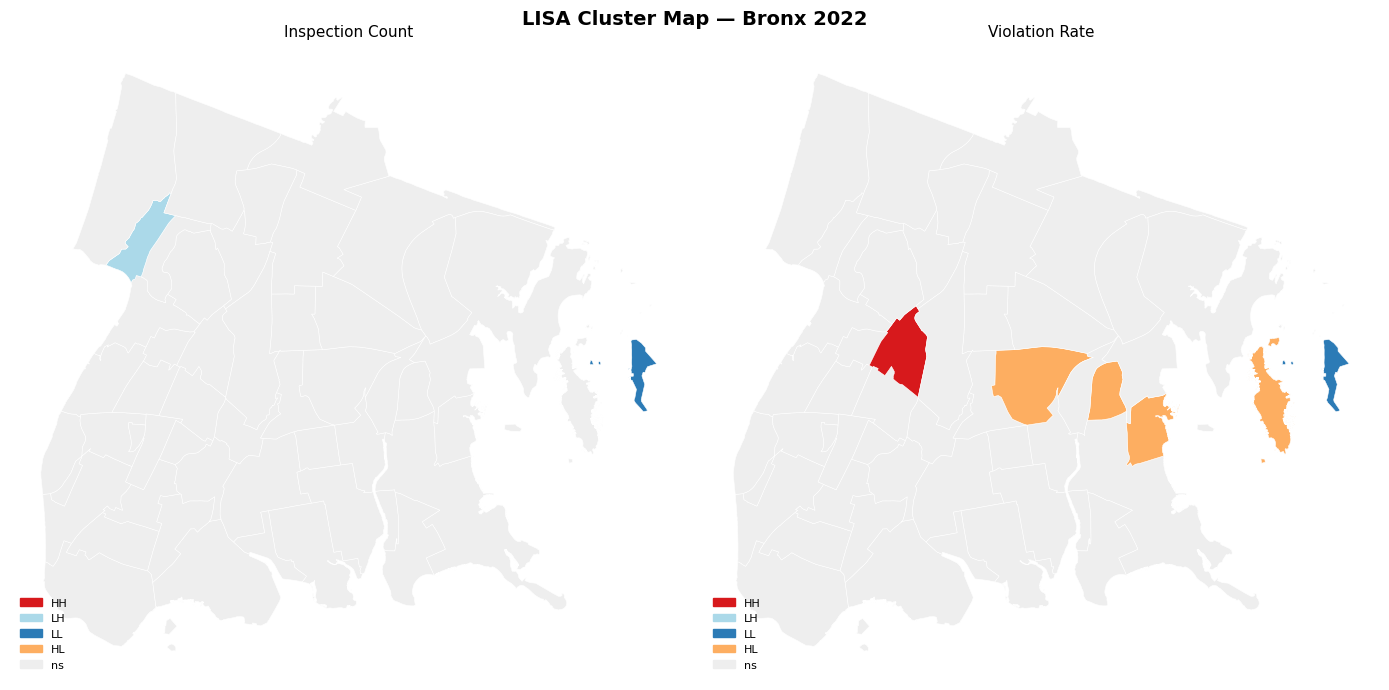

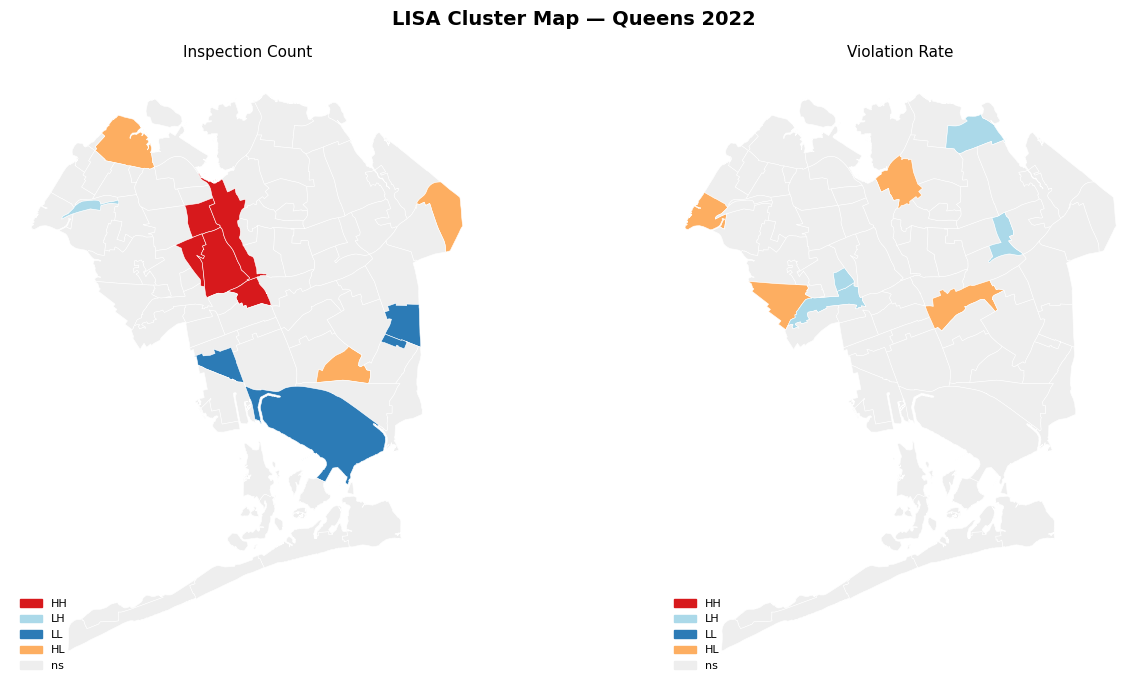

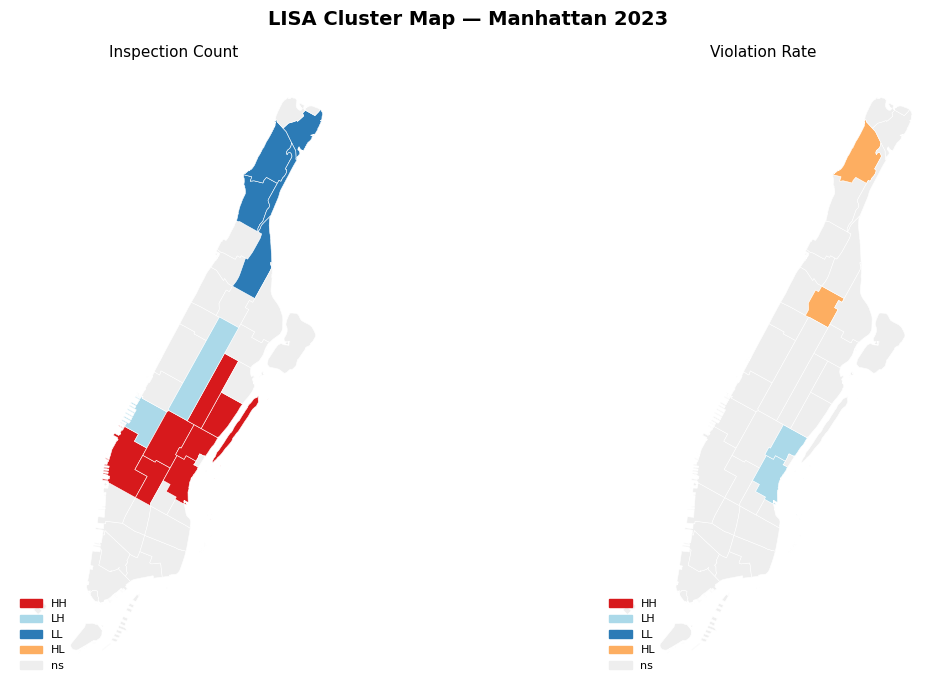

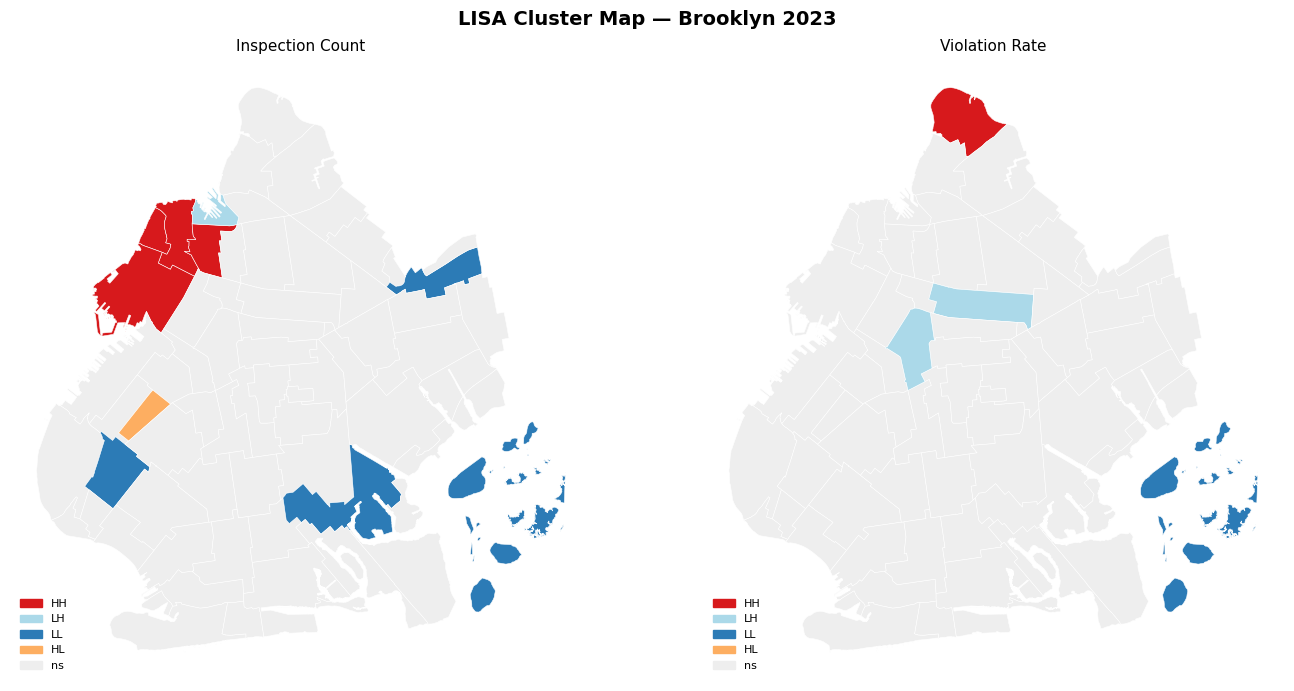

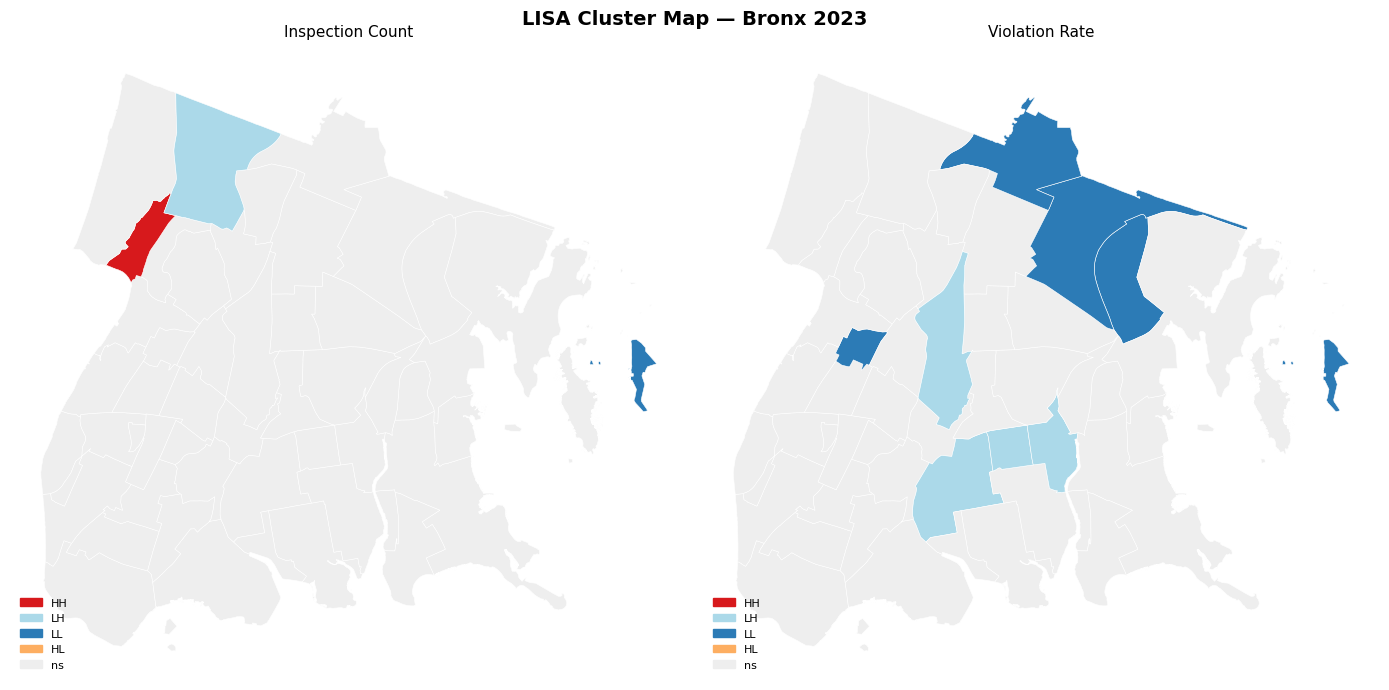

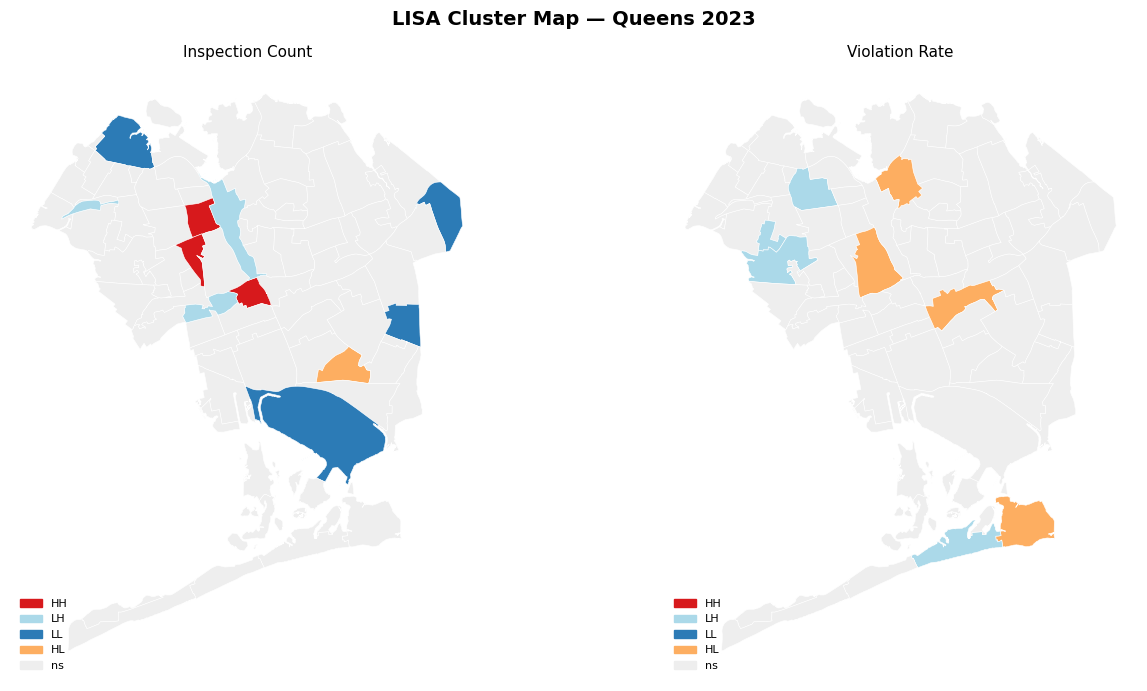

In [35]:
LISA_COLORS = {"HH": "#d7191c", "LH": "#abd9e9", "LL": "#2c7bb6", "HL": "#fdae61", "ns": "#eeeeee"}
QUAD_MAP    = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
SIG         = 0.05

def lisa_labels(lisa_obj):
    labels = np.full(len(lisa_obj.Is), "ns", dtype=object)
    for i, (sig, q) in enumerate(zip(lisa_obj.p_sim < SIG, lisa_obj.q)):
        if sig:
            labels[i] = QUAD_MAP[q]
    return labels

for y in years:
    for b in boroughs:
        gdf = geo_data[y][b].copy()
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        fig.suptitle(f"LISA Cluster Map — {b.title()} {int(y)}", fontsize=14, fontweight="bold")

        for ax, var in zip(axes, ["inspection_count", "violation_rate"]):
            labels = lisa_labels(local_results[y][b][var])
            gdf.plot(color=[LISA_COLORS[l] for l in labels], linewidth=0.4, edgecolor="white", ax=ax)
            ax.set_title(var.replace("_", " ").title(), fontsize=11)
            ax.axis("off")
            ax.legend(handles=[mpatches.Patch(color=v, label=k) for k, v in LISA_COLORS.items()], loc="lower left", fontsize=8, frameon=False)

        plt.tight_layout()
        fname = f"lisa_{b.replace(' ', '_')}_{int(y)}.png"
        plt.show()
